In [1]:
import numpy as np
import matplotlib
from IPython import get_ipython

ip = get_ipython()
selected_backend = None
backend_error = None

for candidate in ("tk", "notebook", "inline"):
    try:
        if ip is not None:
            ip.run_line_magic("matplotlib", candidate)
        else:
            matplotlib.use({"tk": "TkAgg", "notebook": "nbAgg", "inline": "Agg"}[candidate])
        selected_backend = candidate
        break
    except Exception as exc:
        backend_error = exc

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print(f"Matplotlib backend: {matplotlib.get_backend()} (mode: {selected_backend})")
if backend_error is not None and selected_backend != "tk":
    print(f"Tk backend unavailable, using {selected_backend}: {backend_error}")

Matplotlib backend: inline (mode: inline)
Tk backend unavailable, using inline: Failed to import tkagg backend. You appear to be using an outdated version of uv's managed Python distribution which is not compatible with Tk. Please upgrade to the latest uv version, then update Python with: `uv python upgrade --reinstall`


In [2]:
import sys
from pathlib import Path
from math import cos, sin, pi, radians

# Make sure ur3e-control is on the path
sys.path.insert(0, str(Path.cwd().parents[1]))

from my_simulation.iscoin_sim.kinematics import (
    analytical_ik,
    forward_kinematics_matrix,
    pose_to_matrix,
    matrix_to_tcp6d,
)

from my_simulation.iscoin_sim import ISCoinSim as ISCoin
from URBasic import Joint6D, TCP6D, is_reachable
from URBasic.waypoint6d import TCP6DDescriptor


# # Connect to the simulator
iscoin = ISCoin()
robot = iscoin.robot_control
print("Connected to simulator")

ISCoinSim connected to container 'iscoin_simulator'
Connected to simulator


In [3]:
# Reload reachability helpers after source edits
import importlib
import URBasic.reachability as reachability_module
from URBasic.reachability import is_reachable

importlib.reload(reachability_module)
from URBasic.reachability import is_reachable

print("Reloaded is_reachable")

Reloaded is_reachable


In [4]:
import trimesh
print(f"trimesh version: {trimesh.__version__}")

trimesh version: 4.11.2


In [5]:
mesh_path = "../3d_objects/cube2.stl"

In [6]:
# mesh_path = "../3d_objects/duckround.stl"

In [7]:
# mesh_path = "../3d_objects/trapez.stl"

In [8]:
obstacle = trimesh.load(mesh_path)
print(f"Loaded: {mesh_path}")
print(f"Type: {type(obstacle)}")

Loaded: ../3d_objects/cube2.stl
Type: <class 'trimesh.base.Trimesh'>


In [9]:
print(f"Vertices: {len(obstacle.vertices)}")
print(f"Faces:    {len(obstacle.faces)}")

Vertices: 8
Faces:    12


Bounds: [-0.1        -0.55000001 -0.1       ] to [ 0.1        -0.35000002  0.1       ]


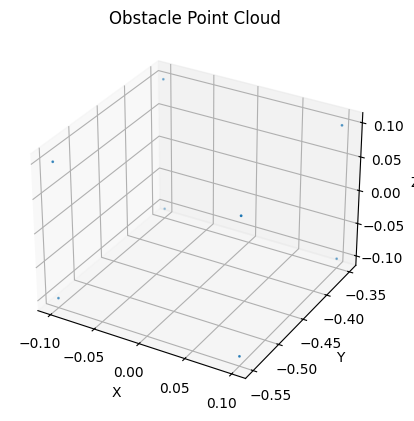

In [10]:
print(f"Bounds: {obstacle.vertices.min(axis=0)} to {obstacle.vertices.max(axis=0)}")

# plot with matplotlib
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.scatter(obstacle.vertices[:, 0], obstacle.vertices[:, 1], obstacle.vertices[:, 2], s=1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Obstacle Point Cloud")
plt.show()

In [ ]:
# Check reachability of all vertices (orientation sweep around ±normal)
obstacles = [{"type": "box", "center": [0.2, -0.4, 0.0], "size": [0.02, 0.1, 0.1]}]
joint_limits = [(-2.0 * np.pi, 2.0 * np.pi)] * 6
roll_samples = 8
include_opposite_normal = False

reachable_count = 0
unreachable_indices = []

# Set TCP offset for the pen extending from the gripper
pen_length = 0.128  # meters
robot.set_tcp(TCP6D.createFromMetersRadians(0, 0, pen_length, 0, 0, 0))

for i, v in enumerate(obstacle.vertices):
    normal = obstacle.vertex_normals[i] if len(obstacle.vertex_normals) == len(obstacle.vertices) else np.array([0.0, 0.0, 1.0])
    target = TCP6D.createFromMetersRadians(v[0], v[1], v[2], normal[0], normal[1], normal[2])

    has_solution = is_reachable(
        robot,
        target,
        obstacles=obstacles,
        joint_limits=joint_limits,
        roll_samples=roll_samples,
        include_opposite_normal=include_opposite_normal,
    )

    if has_solution:
        reachable_count += 1
    else:
        unreachable_indices.append(i)

object_reachable = (len(unreachable_indices) == 0)

print(f"Reachable vertices: {reachable_count}/{len(obstacle.vertices)}")
print(f"Obstacle fully reachable: {object_reachable}")
if unreachable_indices:
    print(f"First unreachable vertex indices: {unreachable_indices[:20]}")

Reachable vertices: 0/8
Obstacle fully reachable: False
First unreachable vertex indices: [0, 1, 2, 3, 4, 5, 6, 7]


In [ ]:
# === Reachability optimization helpers (face sampling + direction from failures) ===

def plot_obstacle(ax, obs):
    kind = str(obs.get("type", "sphere")).lower()
    if kind == "box":
        # Get box corners
        if "min" in obs and "max" in obs:
            box_min = np.array(obs["min"], dtype=float)
            box_max = np.array(obs["max"], dtype=float)
        elif "center" in obs and "size" in obs:
            center = np.array(obs["center"], dtype=float)
            half = 0.5 * np.array(obs["size"], dtype=float)
            box_min = center - half
            box_max = center + half
        else:
            return
        # Draw box as wireframe
        from itertools import product, combinations
        r = [box_min, box_max]
        for s, e in combinations(np.array(list(product(*zip(box_min, box_max)))), 2):
            if np.sum(np.abs(s - e) == np.abs(box_max - box_min)) == 1:
                ax.plot3D(*zip(s, e), color="blue", alpha=0.5, linewidth=2)
    elif kind == "sphere":
        center = np.array(obs["center"], dtype=float)
        radius = float(obs["radius"])
        u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
        x = center[0] + radius * np.cos(u) * np.sin(v)
        y = center[1] + radius * np.sin(u) * np.sin(v)
        z = center[2] + radius * np.cos(v)
        ax.plot_wireframe(x, y, z, color="orange", alpha=0.5)

def translated_mesh(mesh, translation):
    """Return a copy of mesh translated by a 3D vector."""
    mesh_out = mesh.copy()
    mesh_out.apply_translation(np.array(translation, dtype=float))
    return mesh_out

def _safe_unit_normal(n, fallback=np.array([0.0, 0.0, 1.0])):
    """Return a unit normal, or fallback if norm is too small."""
    n = np.array(n, dtype=float)
    norm = np.linalg.norm(n)
    if norm <= 1e-12:
        fb = np.array(fallback, dtype=float)
        fb_norm = np.linalg.norm(fb)
        if fb_norm <= 1e-12:
            return np.array([0.0, 0.0, 1.0], dtype=float)
        return fb / fb_norm
    return n / norm

def sample_points_on_faces(mesh, points_per_face=3, seed=42):
    """Sample random points uniformly on each triangle face.

    Returns:
        points: (N, 3) array
        normals: (N, 3) array face normals associated with each sampled point
        face_ids: (N,) face index for each point
    """
    points_per_face = int(points_per_face)
    if points_per_face < 1:
        raise ValueError("points_per_face must be >= 1")

    rng = np.random.default_rng(seed)
    vertices = mesh.vertices
    faces = mesh.faces
    has_face_normals = len(mesh.face_normals) == len(faces)

    sampled_points = []
    sampled_normals = []
    sampled_face_ids = []

    for face_id, tri in enumerate(faces):
        v0, v1, v2 = vertices[tri[0]], vertices[tri[1]], vertices[tri[2]]

        # Prefer mesh face normal; fallback to geometric normal from triangle
        if has_face_normals:
            n_raw = mesh.face_normals[face_id]
        else:
            n_raw = np.cross(v1 - v0, v2 - v0)
        n_geom = np.cross(v1 - v0, v2 - v0)
        n = _safe_unit_normal(n_raw, fallback=n_geom)

        r1 = rng.random(points_per_face)
        r2 = rng.random(points_per_face)
        sr1 = np.sqrt(r1)

        pts = (
            (1.0 - sr1)[:, None] * v0
            + (sr1 * (1.0 - r2))[:, None] * v1
            + (sr1 * r2)[:, None] * v2
        )

        sampled_points.append(pts)
        sampled_normals.append(np.tile(n, (points_per_face, 1)))
        sampled_face_ids.append(np.full(points_per_face, face_id, dtype=int))

    points = np.vstack(sampled_points)
    normals = np.vstack(sampled_normals)
    face_ids = np.concatenate(sampled_face_ids)
    return points, normals, face_ids

def evaluate_mesh_face_samples(
    mesh,
    robot,
    joint_limits,
    *,
    points_per_face=3,
    seed=42,
    roll_samples=12,
    include_opposite_normal=True,
):
    """Evaluate reachability on random samples per face."""
    points, normals, face_ids = sample_points_on_faces(
        mesh, points_per_face=points_per_face, seed=seed
    )

    reachable_mask = np.zeros(len(points), dtype=bool)
    for i, (p, n) in enumerate(zip(points, normals)):
        n_safe = _safe_unit_normal(n)
        target = TCP6D.createFromMetersRadians(
            float(p[0]), float(p[1]), float(p[2]),
            float(n_safe[0]), float(n_safe[1]), float(n_safe[2])
        )

        reachable_mask[i] = bool(
            is_reachable(
                robot,
                target,
                obstacles=obstacles,
                joint_limits=joint_limits,
                roll_samples=roll_samples,
                include_opposite_normal=include_opposite_normal,
            )
        )

    reachable = int(reachable_mask.sum())
    total = int(len(points))
    unreachable_idx = np.flatnonzero(~reachable_mask).astype(int).tolist()

    return {
        "reachable": reachable,
        "total": total,
        "ratio": float(reachable) / float(total) if total else 0.0,
        "unreachable_indices": unreachable_idx,
        "reachable_mask": reachable_mask,
        "points": points,
        "normals": normals,
        "face_ids": face_ids,
    }

def suggested_translation_from_failures(points, reachable_mask, base=np.zeros(3)):
    """Infer translation direction from failed points.

    Heuristic: move the object so failed points are pulled toward the robot base.
    Returns a unit direction vector (or zeros if undefined).
    """
    failed = points[~reachable_mask]
    if len(failed) == 0:
        return np.zeros(3, dtype=float)

    vectors = np.array(base, dtype=float)[None, :] - failed
    norms = np.linalg.norm(vectors, axis=1)
    valid = norms > 1e-9
    if not np.any(valid):
        return np.zeros(3, dtype=float)

    unit_vectors = vectors[valid] / norms[valid, None]
    direction = unit_vectors.mean(axis=0)
    n = np.linalg.norm(direction)
    if n < 1e-9:
        return np.zeros(3, dtype=float)
    return direction / n

def plot_shape_and_test_points(mesh, points, reachable_mask, base=np.zeros(3), title="Reachability samples"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_trisurf(
        mesh.vertices[:, 0], mesh.vertices[:, 1], mesh.vertices[:, 2],
        triangles=mesh.faces, alpha=0.18, color='gray', edgecolor='gray', linewidth=0.1
    )

    reachable_pts = points[reachable_mask]
    failed_pts = points[~reachable_mask]
    if len(reachable_pts):
        ax.scatter(*reachable_pts.T, c='green', s=14, alpha=0.8, label='Reachable')
    if len(failed_pts):
        ax.scatter(*failed_pts.T, c='red', s=18, alpha=0.9, label='Not reachable')

    base = np.array(base, dtype=float)
    ax.scatter(base[0], base[1], base[2], c='black', s=110, marker='*', label='Arm base (0,0,0)')

    # Plot obstacles if available
    if obstacles is not None:
        if isinstance(obstacles, dict):
            plot_obstacle(ax, obstacles)
        elif isinstance(obstacles, list):
            for obs in obstacles:
                plot_obstacle(ax, obs)

    all_pts = np.vstack([mesh.vertices, points, base[None, :]])
    lo, hi = all_pts.min(axis=0), all_pts.max(axis=0)
    mid = (lo + hi) / 2.0
    half = max(1e-3, (hi - lo).max() / 2.0)
    pad = 0.15 * half

    ax.set_xlim(mid[0] - half - pad, mid[0] + half + pad)
    ax.set_ylim(mid[1] - half - pad, mid[1] + half + pad)
    ax.set_zlim(min(0.0, lo[2] - pad), mid[2] + half + pad)

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    ax.legend()
    ax.set_box_aspect([1, 1, 1])
    plt.tight_layout()
    plt.show()

print("Face-sampling helpers defined")

Face-sampling helpers defined


Iterative search with random points on each face...
iter=00 -> 1/12 (8.3%)


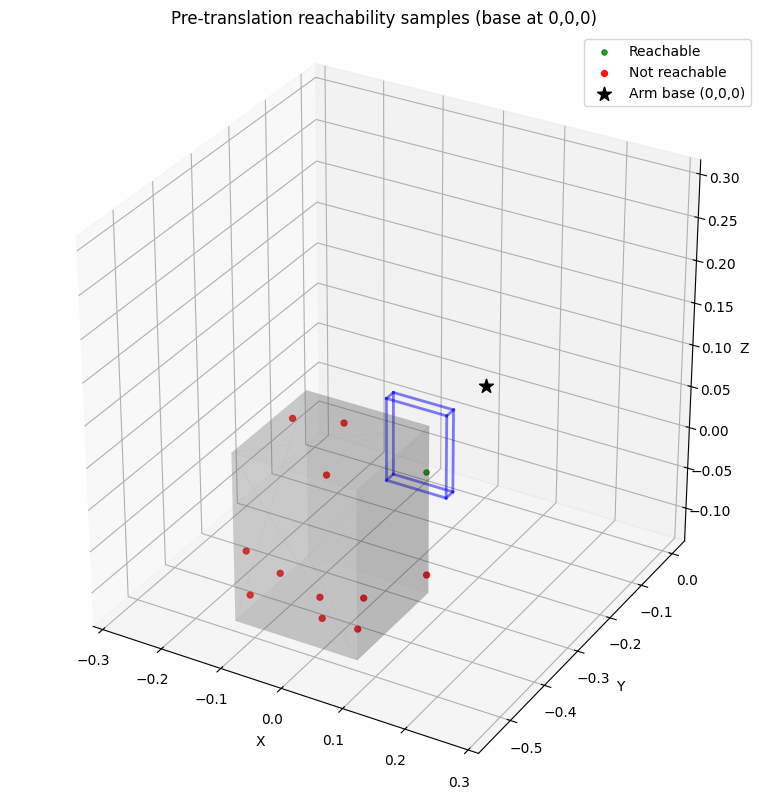

  move_dir=[0.009, 0.9989, 0.0469] step=0.042 delta=[0.0004, 0.0425, 0.002]
iter=01 -> 5/12 (41.7%)
  move_dir=[-0.0999, 0.9946, 0.0261] step=0.032 delta=[-0.0032, 0.0323, 0.0008]
iter=02 -> 4/12 (33.3%)
  move_dir=[-0.0769, 0.9946, 0.0697] step=0.035 delta=[-0.0027, 0.0348, 0.0024]
iter=03 -> 6/12 (50.0%)
  move_dir=[0.0385, 0.9989, -0.0285] step=0.030 delta=[0.0012, 0.03, -0.0009]
iter=04 -> 6/12 (50.0%)
  move_dir=[0.06, 0.9813, 0.1827] step=0.030 delta=[0.0018, 0.0294, 0.0055]
iter=05 -> 7/12 (58.3%)
  move_dir=[0.1459, 0.985, -0.0916] step=0.027 delta=[0.004, 0.0271, -0.0025]
iter=06 -> 5/12 (41.7%)
  move_dir=[0.0587, 0.9941, 0.0908] step=0.032 delta=[0.0019, 0.0323, 0.003]
iter=07 -> 6/12 (50.0%)
  move_dir=[0.1821, 0.9821, 0.0487] step=0.030 delta=[0.0055, 0.0295, 0.0015]
Stopped before reaching full reachability on sampled points
Current total translation: [0.0088, 0.2579, 0.0118]
Last status: 6/12 (50.0%)


In [13]:
# === Iterative translation search driven by failed sample points ===
joint_limits_local = globals().get("joint_limits", [(-2.0 * np.pi, 2.0 * np.pi)] * 6)
roll_samples_local = int(globals().get("roll_samples", 12))
include_opposite_normal_local = bool(globals().get("include_opposite_normal", False))

points_per_face = 1   # <--- set x random points per face here
max_iters = 8
base_step = 0.03      # meters
seed0 = 42

show_pre_translation_plot = True
pre_translation_plot_done = False

candidate = obstacle.copy()
total_translation = np.zeros(3, dtype=float)
history = []
last_stats = None
found = False

print("Iterative search with random points on each face...")
for it in range(max_iters):
    stats = evaluate_mesh_face_samples(
        candidate,
        robot,
        joint_limits_local,
        points_per_face=points_per_face,
        seed=seed0 + it,
        roll_samples=roll_samples_local,
        include_opposite_normal=include_opposite_normal_local,
    )
    last_stats = stats
    history.append(stats)

    print(
        f"iter={it:02d} -> {stats['reachable']}/{stats['total']} "
        f"({100.0 * stats['ratio']:.1f}%)"
    )

    # Plot once BEFORE any translation is applied
    if show_pre_translation_plot and not pre_translation_plot_done:
        plot_shape_and_test_points(
            candidate,
            stats["points"],
            stats["reachable_mask"],
            base=np.array([0.0, 0.0, 0.0]),
            title="Pre-translation reachability samples (base at 0,0,0)",
        )
        pre_translation_plot_done = True

    if stats["reachable"] == stats["total"]:
        found = True
        obstacle = candidate
        bbox_min, bbox_max = obstacle.bounds
        print("Success: all sampled face points reachable")
        print(f"Applied total translation: {total_translation.tolist()}")
        break

    move_dir = suggested_translation_from_failures(
        stats["points"],
        stats["reachable_mask"],
        base=np.array([0.0, 0.0, 0.0]),
    )

    if np.linalg.norm(move_dir) < 1e-9:
        print("No clear movement direction from failures — stopping")
        break

    failed_ratio = 1.0 - stats["ratio"]
    step = base_step * (0.5 + failed_ratio)
    step = float(np.clip(step, 0.01, 0.06))

    delta = step * move_dir
    candidate = translated_mesh(candidate, delta)
    total_translation += delta

    print(f"  move_dir={np.round(move_dir, 4).tolist()} step={step:.3f} delta={np.round(delta, 4).tolist()}")

if not found:
    print("Stopped before reaching full reachability on sampled points")
    print(f"Current total translation: {np.round(total_translation, 4).tolist()}")
    if last_stats is not None:
        print(
            f"Last status: {last_stats['reachable']}/{last_stats['total']} "
            f"({100.0 * last_stats['ratio']:.1f}%)"
        )

# Keep these for plotting in the next cell
reachability_last_stats = last_stats
reachability_total_translation = total_translation

In [ ]:
# === Plot tested points + arm base ===
if reachability_last_stats is None:
    print("No reachability stats available. Run the previous cell first.")
else:
    print(obstacle.centroid)
    plot_shape_and_test_points(
        obstacle,
        reachability_last_stats["points"],
        reachability_last_stats["reachable_mask"],
        base=np.array([0.0, 0.0, 0.0]),
        title="Shape reachability samples (base at 0,0,0)",
    )